## **0. EXECUTIVE SUMMARY**

**Ringkasan Temuan Utama**

Analisis terhadap 300.000 data pengiriman JNE mengungkap beberapa masalah signifikan yang berdampak pada efisiensi operasional, kepuasan pelanggan, dan pendapatan perusahaan:

1. **Pelanggaran SLA Pengiriman**

Tingkat SLA Miss secara keseluruhan mencapai 45,79%. Penyebab utamanya bukan karena kinerja cabang yang buruk, melainkan karena durasi pengiriman aktual antar jenis layanan (REG, YES, OKE) yang hampir identik (rata-rata 3,49-3,51 hari), padahal SLA yang dijanjikan berbeda signifikan (YES=1 hari, REG=3 hari, OKE=6 hari). Breakdown per cabang mengonfirmasi bahwa masalah ini tersebar merata (rate tertinggi hanya 48,53%, tidak jauh dari rata-rata nasional), membuktikan bahwa dugaan awal JNE terkait kinerja cabang tidak tepat — permasalahan ini bersifat sistemik, terkait kebijakan diferensiasi layanan JNE secara nasional.

2. **RTS Tinggi pada Metode Pembayaran COD**

Tingkat retur (RTS) pada COD mencapai 24,96%, jauh lebih tinggi dibanding Non-COD (4,96%) — mengonfirmasi dugaan bisnis soal penolakan pembayaran dan alamat fiktif. Estimasi kerugian operasional mencapai Rp392.820.000 (asumsi Rp15.000/kejadian). Masalah ini juga tersebar merata di seluruh kota, menunjukkan ini adalah karakteristik risiko metode COD itu sendiri, bukan masalah regional.

3. **Kebocoran Pendapatan dari Kesalahan Input Data Agen**

Ditemukan 1.500 baris (0,5%) data weight_kg yang tidak wajar, terdiri dari 769 baris bernilai negatif (human error input) dan 731 baris bernilai identik 999/9999 (bug sistem timbangan digital). Estimasi kerugian mencapai Rp24.415.000 (asumsi tarif Rp10.000/kg). Kedua jenis anomali ini tersebar merata di seluruh cabang, mengindikasikan masalah sistemik.

4. **Missing Values pada Data Pelanggan**

Sebanyak 4.579 dari 30.000 data pelanggan (15,26%) memiliki customer_type yang kosong, menghambat tim Sales dalam segmentasi cross-selling. Masalah ini tersebar merata (14,41%-15,88% per kota).

5. **Data Quality: Logical Error pada Timestamp**

Ditemukan 7.473 baris (2,49%) dengan delivered_date yang tercatat lebih awal dari pickup_date. Error ini juga tersebar merata di seluruh cabang (rate 2,99%-3,88%), mengindikasikan bug pada sistem scanning barcode.

6. **Inkonsistensi Penulisan Service Type**

Ditemukan 9 variasi penulisan untuk 3 jenis layanan (REG, YES, OKE) akibat input manual agen tanpa standar. Setelah dibersihkan: REG 149.835 (49,9%), OKE 75.125 (25,0%), YES 75.040 (25,0%).

**Insight Kunci: Pola Sistemik, Bukan Lokal**

Keenam temuan di atas memiliki pola yang konsisten: seluruh anomali data tersebar merata secara geografis, tidak terkonsentrasi di cabang atau kota tertentu. Ini menunjukkan bahwa akar masalah JNE bersifat sistemik (kebijakan/infrastruktur/SOP), bukan disebabkan oleh oknum atau kondisi lokal tertentu — sehingga solusi yang dibutuhkan juga harus bersifat nasional dan menyeluruh, bukan audit atau intervensi ke lokasi tertentu.

Prioritas Rekomendasi

Urutan prioritas berikut disusun berdasarkan dua pertimbangan utama: (1) dampak terhadap kepercayaan dan kepuasan pelanggan sebagai prinsip fundamental bisnis jasa, dan (2) besaran dampak finansial yang telah terverifikasi.

| Prioritas | Masalah | Dasar Pertimbangan |
|---|---|---|
| 1 | Pelanggaran SLA | Cakupan terluas |
| 2 | RTS pada COD | Kerugian finansial terbesar |
| 3 | Weight Anomaly | Kerugian finansial signifikan |
| 4 | Missing customer_type | Peluang cross-selling yang hilang |
| 5 | Logical error & inkonsistensi service_type | Prasyarat keandalan data untuk pelaporan dan dashboard yang akurat |

Perlu dicatat bahwa penanganan SLA Miss sebagai prioritas utama juga berpotensi mencegah membesarnya masalah lain secara jangka panjang — pelanggan yang kecewa akibat keterlambatan pengiriman berisiko meningkatkan angka penolakan penerimaan paket (RTS) di masa mendatang, sehingga perbaikan pada aspek ini turut memberikan efek pencegahan terhadap eskalasi masalah lainnya.

## **1. INTRODUCTION & BUSINESS UNDERSTANDING**

### Background & bisnis JNE

Ledakan industri e-commerce di Indonesia dalam satu dekade terakhir membawa berkah sekaligus tantangan masif bagi perusahaan logistik veteran seperti JNE. Sebagai salah satu pelopor jasa ekspedisi di tanah air, JNE memiliki jaringan infrastruktur yang sangat luas, menjangkau hingga ke pelosok kecamatan. Setiap harinya, ratusan ribu hingga jutaan paket bergerak melalui sorting hub (pusat sortir), truk antar-kota, hingga armada kurir last-mile yang mengantarkan barang langsung ke depan pintu rumah pelanggan.

Namun, seiring dengan meningkatnya volume pengiriman, ekspektasi konsumen juga semakin tinggi. Pelanggan kini menuntut pengiriman yang serba cepat, murah, dan bisa dilacak secara real-time. Layanan premium seperti JNE YES (Yakin Esok Sampai) menjadi standar baru kepuasan pelanggan. Sayangnya, infrastruktur operasional di lapangan seringkali kewalahan menghadapi lonjakan volume paket, terutama saat event tanggal kembar (mega campaign e-commerce). Hal ini menyebabkan tumpukan barang di gudang sortir dan memicu pelanggaran batas waktu pengiriman yang dijanjikan atau Service Level Agreement (SLA Miss).

Selain masalah SLA, tren pembayaran Cash on Delivery (COD) yang sangat populer di kota-kota tier 2 dan 3 menimbulkan kerugian operasional yang signifikan. Banyak kasus di mana kurir sudah mengantar barang sampai ke alamat tujuan, namun pembeli menolak membayar, atau alamat yang dicantumkan ternyata fiktif. Akibatnya, paket harus dikembalikan ke penjual (Return to Sender / RTS). Proses retur ini memakan biaya bahan bakar dan tenaga kerja dua kali lipat, namun JNE tidak mendapatkan bayaran penuh atas jasa pengiriman yang gagal tersebut.

Di level pendataan sistem, tim IT dan Data mendapati bahwa database pengiriman harian penuh dengan anomali. Sistem input manual dari agen-agen di daerah seringkali menghasilkan penulisan layanan yang tidak standar. Berat paket yang ditimbang seringkali tidak masuk akal (sangat berat atau bahkan minus), yang mengindikasikan kebocoran pendapatan (revenue leakage) karena ongkir dibayar lebih murah dari yang seharusnya. Ditambah lagi, mesin scanner barcode yang kadang error membuat timestamp perjalanan paket menjadi kacau balau.

Oleh karena itu, analisis mendalam terhadap data pengiriman, performa cabang (branch), dan tingkat keberhasilan COD ini mutlak harus segera dilakukan. Tanpa adanya identifikasi titik bottleneck di jalur distribusi dan pembersihan data tracking yang akurat, JNE akan terus menderita kerugian operasional akibat paket retur dan kalah bersaing dengan kompetitor logistik baru yang lebih tech-savvy. Analisis ini adalah langkah pertama untuk merevolusi efisiensi operasional dari hulu ke hilir.


### Problem Statement

**Masalah Utama:** 
Tingginya biaya operasional (inefisiensi) yang disebabkan oleh pelanggaran SLA pengiriman, lonjakan paket retur (RTS) dari layanan COD, dan kebocoran pendapatan akibat input data agen yang kotor.

**Masalah Turunan:**
1.	Cabang atau sorting hub mana yang paling sering menjadi titik bottleneck sehingga paket terlambat sampai ke konsumen (SLA Miss)?
2.	Bagaimana perbandingan tingkat retur (RTS) antara paket yang menggunakan metode pembayaran COD versus Non-COD?
3.	Seberapa besar estimasi kebocoran pendapatan akibat anomali input berat paket (weight outliers) yang lebih rendah dari berat aslinya?
4.	Layanan apa (REG, YES, OKE) yang paling sering mengalami ketidakkonsistenan penulisan di database, yang menyulitkan agregasi pelaporan?
5.	(Logical Error) Seberapa banyak paket yang tercatat memiliki status "Delivered" (Sampai), namun timestamp-nya terjadi sebelum paket tersebut di-"Pickup" (Dijemput) oleh kurir?
6.	Berapa persentase data pengirim (Corporate/Individual) yang kosong (missing values), yang menghambat tim Sales melakukan cross-selling?


### Goals

**Jika analisis ini dipecahkan, target operasional yang akan dicapai adalah:**

1.	**Route & Hub Optimization:** Menemukan dan mengevaluasi cabang yang kinerjanya buruk, sehingga angka keterlambatan (SLA Miss) turun minimal 15%.
2.	**COD Risk Management:** Membangun blacklist atau aturan pengetatan layanan COD di daerah-daerah dengan rate RTS tertinggi untuk memangkas biaya retur.
3.	**Revenue Recovery:** Memperbaiki sistem input berat barang di level agen untuk menghentikan kebocoran omzet dari ongkos kirim yang tidak sesuai.
4.	**Data Reliability:** Memiliki pipeline data tracking yang bersih dari logical error, sehingga dashboard performa kurir dan SLA menampilkan angka yang valid.


## **2. DATA UNDERSTANDING**

### 2.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

### 2.2 Load data CSV

In [2]:
customers = pd.read_csv('jne_customers.csv')
branches = pd.read_csv('jne_branches.csv')
shipments = pd.read_csv('jne_shipments.csv')

### 2.3 Mengecek jumlah kolom & baris tiap data

In [3]:
print(customers.shape, branches.shape, shipments.shape)

(30000, 3) (150, 3) (300000, 10)


### 2.4 Mengecek tipe data tiap kolom

#### 2.4.1 Data customers

In [4]:
print(customers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    30000 non-null  object
 1   city           30000 non-null  object
 2   customer_type  25421 non-null  object
dtypes: object(3)
memory usage: 703.3+ KB
None


Hanya 25421 non-null di customer type dari 30000 baris, sehingga ada 4579 missing values.

#### 2.4.2 Data branches

In [5]:
print(branches.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   branch_code  150 non-null    object
 1   branch_name  150 non-null    object
 2   region       150 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB
None


#### 2.4.3 Data shipments

In [6]:
print(shipments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   awb_number      300000 non-null  object 
 1   sender_id       300000 non-null  object 
 2   origin_branch   300000 non-null  object 
 3   dest_city       300000 non-null  object 
 4   service_type    300000 non-null  object 
 5   payment_type    300000 non-null  object 
 6   weight_kg       300000 non-null  float64
 7   pickup_date     300000 non-null  object 
 8   delivered_date  300000 non-null  object 
 9   status          300000 non-null  object 
dtypes: float64(1), object(9)
memory usage: 22.9+ MB
None


### 2.5 Melihat contoh data mentah

#### 2.5.1 Data customer

In [7]:
print(customers.head())
print(customers.sample(10))

  customer_id      city customer_type
0  CUST-00001  Makassar    Individual
1  CUST-00002  Makassar    Individual
2  CUST-00003  Makassar    Individual
3  CUST-00004  Denpasar    Individual
4  CUST-00005     Medan           NaN
      customer_id        city customer_type
25146  CUST-25147  Yogyakarta    Individual
18060  CUST-18061  Yogyakarta     Corporate
124    CUST-00125     Bandung    Individual
24850  CUST-24851     Jakarta     Corporate
4388   CUST-04389     Bandung    Individual
3818   CUST-03819     Jakarta    Individual
14190  CUST-14191    Surabaya    Individual
20996  CUST-20997    Semarang     Corporate
28392  CUST-28393   Palembang    Individual
1819   CUST-01820       Medan     Corporate


#### 2.5.2 Data branches

In [8]:
print(branches.head())
print(branches.sample(10))

  branch_code         branch_name       region
0       B-001  JNE Cabang Utama 1     Sumatera
1       B-002  JNE Cabang Utama 2     Sumatera
2       B-003  JNE Cabang Utama 3   Kalimantan
3       B-004  JNE Cabang Utama 4  Jabodetabek
4       B-005  JNE Cabang Utama 5   Jawa Barat
    branch_code           branch_name       region
33        B-034   JNE Cabang Utama 34  Jawa Tengah
35        B-036   JNE Cabang Utama 36     Sulawesi
12        B-013   JNE Cabang Utama 13     Sulawesi
92        B-093   JNE Cabang Utama 93   Bali-Nusra
47        B-048   JNE Cabang Utama 48   Kalimantan
147       B-148  JNE Cabang Utama 148     Sumatera
10        B-011   JNE Cabang Utama 11   Jawa Barat
87        B-088   JNE Cabang Utama 88     Sulawesi
69        B-070   JNE Cabang Utama 70   Jawa Barat
19        B-020   JNE Cabang Utama 20   Kalimantan


#### 2.5.3 Data shipments

In [9]:
print(shipments.head())
print(shipments.sample(10))

     awb_number   sender_id origin_branch   dest_city       service_type  \
0  JNE000000001  CUST-25624         B-035  Yogyakarta            Reguler   
1  JNE000000002  CUST-17057         B-054   Palembang                REG   
2  JNE000000003  CUST-27196         B-104  Yogyakarta                YES   
3  JNE000000004  CUST-15447         B-097       Medan                REG   
4  JNE000000005  CUST-20847         B-147    Surabaya  Yakin Esok Sampai   

  payment_type  weight_kg          pickup_date       delivered_date     status  
0      Prepaid        9.5  2023-05-12 17:00:00  2023-05-18 22:00:00  Delivered  
1          COD       19.5  2023-05-02 15:00:00  2023-05-08 00:00:00        RTS  
2      Prepaid       14.8  2023-10-25 17:00:00  2023-10-27 19:00:00  Delivered  
3      Prepaid       16.3  2023-10-09 09:00:00  2023-10-14 19:00:00  Delivered  
4      Prepaid        1.1  2023-08-22 09:00:00  2023-08-24 20:00:00  Delivered  
          awb_number   sender_id origin_branch   dest_cit

### 2.6 Statistik Dasar Kolom Numerik

#### 2.6.1 Data customer

In [10]:
customers.describe()

,customer_id,city,customer_type
count,30000,30000,25421
unique,30000,10,2
top,CUST-00001,Yogyakarta,Individual
freq,1,3090,17896


#### 2.6.2 Data branches

In [11]:
branches.describe()

,branch_code,branch_name,region
count,150,150,150
unique,150,150,8
top,B-001,JNE Cabang Utama 1,Jawa Barat
freq,1,1,28


#### 2.6.3 Data shipments

In [12]:
shipments.describe()

,weight_kg
count,300000.000000
mean,23.845689
std,350.372839
min,-5.000000
25%,5.700000
50%,10.500000
75%,15.300000
max,9999.000000


### 2.7 Cek missing values

#### 2.7.1 Data customers

In [13]:
customers.isnull().sum()

customer_id         0
city                0
customer_type    4579
dtype: int64

Terdapat missing values pada kolom **customer_type** sebanyak 4579.

#### 2.7.2 Data branches

In [14]:
branches.isnull().sum()

branch_code    0
branch_name    0
region         0
dtype: int64

#### 2.7.3 Data shipments

In [15]:
shipments.isnull().sum()

awb_number        0
sender_id         0
origin_branch     0
dest_city         0
service_type      0
payment_type      0
weight_kg         0
pickup_date       0
delivered_date    0
status            0
dtype: int64

### 2.8 Cek duplikasi

#### 2.8.1 Data customers

In [16]:
customers.duplicated().sum()

np.int64(0)

#### 2.8.2 Data branches

In [17]:
branches.duplicated().sum()

np.int64(0)

#### 2.8.3 Data shipments

In [18]:
shipments.duplicated().sum()

np.int64(0)

## **3. DATA CLEANING**

### 3.1 Convert tipe data

Dikarenakan sebelumnya kolom pickup_date & delivered_date adalah tipe data object, maka perlu dikonversi ke Tanggal.

In [19]:
shipments['pickup_date'] = pd.to_datetime(shipments['pickup_date'])
shipments['delivered_date'] = pd.to_datetime(shipments['delivered_date'])

Melakukan pengecekan apakah kolom pickup_date & delivered_date sudah berubah menjad datetime.

In [20]:
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   awb_number      300000 non-null  object        
 1   sender_id       300000 non-null  object        
 2   origin_branch   300000 non-null  object        
 3   dest_city       300000 non-null  object        
 4   service_type    300000 non-null  object        
 5   payment_type    300000 non-null  object        
 6   weight_kg       300000 non-null  float64       
 7   pickup_date     300000 non-null  datetime64[ns]
 8   delivered_date  300000 non-null  datetime64[ns]
 9   status          300000 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 22.9+ MB


### 3.2 Logical Error

In [21]:
logical_error = shipments[shipments['delivered_date'] < shipments['pickup_date']]

In [22]:
jumlah_error = logical_error.shape[0]
total_data = shipments.shape[0]
persentase = jumlah_error / total_data * 100

print(f"Jumlah logical error: {jumlah_error}")
print(f"Persentase dari total data: {persentase:.2f}%")

Jumlah logical error: 7473
Persentase dari total data: 2.49%


In [23]:
logical_error[['awb_number', 'pickup_date', 'delivered_date', 'status']].head(10)

,awb_number,pickup_date,delivered_date,status
21,JNE000000022,2023-07-20 16:00:00,2023-07-17 16:00:00,Delivered
156,JNE000000157,2023-09-27 12:00:00,2023-09-26 12:00:00,Delivered
173,JNE000000174,2023-08-25 10:00:00,2023-08-24 10:00:00,Delivered
293,JNE000000294,2023-06-24 16:00:00,2023-06-21 16:00:00,Delivered
378,JNE000000379,2023-08-09 18:00:00,2023-08-06 18:00:00,Delivered
388,JNE000000389,2023-10-02 15:00:00,2023-10-01 15:00:00,Delivered
405,JNE000000406,2023-10-22 15:00:00,2023-10-19 15:00:00,Delivered
413,JNE000000414,2023-09-19 18:00:00,2023-09-18 18:00:00,Delivered
443,JNE000000444,2023-05-25 09:00:00,2023-05-23 09:00:00,Delivered
595,JNE000000596,2023-05-27 12:00:00,2023-05-26 12:00:00,Delivered


Mengecek logical error apakah tersebar di semua branch, atau hanya di beberapa branch saja

In [24]:
logical_error['origin_branch'].value_counts().head(10)

origin_branch
B-055    77
B-089    64
B-096    64
B-026    62
B-061    62
B-043    62
B-033    61
B-121    61
B-067    60
B-143    59
Name: count, dtype: int64

In [25]:
# Total pengiriman per cabang
total_per_branch = shipments['origin_branch'].value_counts()

# Total error per cabang
error_per_branch = logical_error['origin_branch'].value_counts()

# Menggabungkan jadi satu tabel dan hitung persentase
error_rate = (error_per_branch / total_per_branch * 100).sort_values(ascending=False)
error_rate.head(10)

origin_branch
B-055    3.875189
B-089    3.277010
B-067    3.138075
B-096    3.099274
B-043    3.087649
B-026    3.070827
B-061    3.063241
B-033    3.013834
B-101    3.006329
B-084    2.989691
Name: count, dtype: float64

Temuan: Logical Error pada Timestamp Pengiriman

Ditemukan 7.473 dari 300.000 baris data (2,49%) dengan kondisi 
delivered_date tercatat lebih awal dari pickup_date — sebuah kondisi 
yang mustahil secara logika.

Setelah dianalisis lebih lanjut per cabang, rate error tertinggi 
hanya berkisar 3-3,9% (cabang B-055 sebagai yang tertinggi), 
tidak jauh berbeda dari rata-rata nasional 2,49%. Hal ini mengindikasikan 
bahwa error bersifat tersebar merata (sistemik), bukan terkonsentrasi 
akibat kesalahan oknum atau alat yang rusak di cabang tertentu.

Rekomendasi: perbaikan difokuskan pada infrastruktur sistem scanning 
secara menyeluruh, bukan audit spesifik ke cabang tertentu.

In [26]:
shipments['is_logical_error'] = shipments['delivered_date'] < shipments['pickup_date']

In [85]:
# Melihat contoh baris yang bermasalah (logical error)
print(shipments[shipments['is_logical_error'] == True].head())

# Menghitung berapa banyak yang bermasalah
print(shipments['is_logical_error'].sum())

# Contoh data bersih (analisis lanjutan pakai data ini)
print(shipments[shipments['is_logical_error'] == False].head())

       awb_number   sender_id origin_branch  dest_city service_type  \
21   JNE000000022  CUST-26206         B-005    Jakarta          yes   
156  JNE000000157  CUST-17645         B-138      Medan          reg   
173  JNE000000174  CUST-16620         B-054  Palembang          YES   
293  JNE000000294  CUST-21591         B-014    Bandung      Reguler   
378  JNE000000379  CUST-29332         B-064      Medan          YES   

    payment_type  weight_kg         pickup_date      delivered_date  \
21       Prepaid        4.1 2023-07-20 16:00:00 2023-07-17 16:00:00   
156          COD        4.2 2023-09-27 12:00:00 2023-09-26 12:00:00   
173          COD        8.0 2023-08-25 10:00:00 2023-08-24 10:00:00   
293          COD        3.0 2023-06-24 16:00:00 2023-06-21 16:00:00   
378      Prepaid        9.1 2023-08-09 18:00:00 2023-08-06 18:00:00   

        status  is_logical_error  is_weight_anomaly service_type_clean  \
21   Delivered              True              False                YES  

In [28]:
shipments['is_logical_error'].value_counts()

is_logical_error
False    292527
True       7473
Name: count, dtype: int64

### 3.3 Weight Anomaly

Melihat baris yang mencurigakan dengan menampilkan 20 baris

In [29]:
shipments[shipments['weight_kg'] > 100].sort_values('weight_kg', ascending=False).head()

,awb_number,sender_id,origin_branch,dest_city,service_type,payment_type,weight_kg,pickup_date,delivered_date,status,is_logical_error
243,JNE000000244,CUST-18922,B-021,Jakarta,REG,COD,9999.0,2023-07-14 11:00:00,2023-07-20 21:00:00,Delivered,False
236635,JNE000236636,CUST-06364,B-102,Balikpapan,REG,Prepaid,9999.0,2023-09-19 14:00:00,2023-09-26 01:00:00,Delivered,False
102499,JNE000102500,CUST-10535,B-077,Jakarta,YES,Prepaid,9999.0,2023-10-01 11:00:00,2023-10-07 15:00:00,Delivered,False
172035,JNE000172036,CUST-04007,B-080,Makassar,Reguler,Prepaid,9999.0,2023-05-16 14:00:00,2023-05-17 15:00:00,Delivered,False
101083,JNE000101084,CUST-24382,B-026,Denpasar,OKE,Prepaid,9999.0,2023-08-08 16:00:00,2023-08-09 23:00:00,Delivered,False


Menghitung jumlah di tiap kategori.

In [80]:
# Jumlah baris dengan berat negatif (mustahil secara fisik)
(shipments['weight_kg'] <= 0).sum()

np.int64(769)

In [81]:
# Jumlah baris di atas batas wajar (threshold dari perhitungan IQR)
(shipments['weight_kg'] > 30).sum()

np.int64(731)

In [82]:
# Jumlah baris dengan berat ekstrem (>100kg, kemungkinan besar error sistem)
(shipments['weight_kg'] > 100).sum()

np.int64(731)

In [ ]:
# Cek apakah ada data di antara 30-100kg
((shipments['weight_kg'] > 30) & (shipments['weight_kg'] <= 100)).sum()

np.int64(0)

Temuan: Weight Anomaly

Ditemukan 1.500 baris (0,5%) dengan nilai weight_kg yang tidak wajar,
terbagi menjadi dua pola berbeda:

1. **769 baris bernilai negatif** — mengindikasikan kesalahan input manual 
   dari petugas/agen di lapangan.
2. **731 baris bernilai tepat 999.0 atau 9999.0** — nilai yang identik ini mengindikasikan 
   default/error value dari sistem ketika alat penimbang gagal membaca berat 
   sebenarnya, bukan kesalahan input acak.

Rekomendasi: 
- Untuk kasus negatif, perlu validasi input di level aplikasi/form agen 
  (tidak boleh menerima angka negatif).
- Untuk kasus 999/9999, perlu investigasi ke tim IT terkait bug pada sistem 
  timbangan digital yang menghasilkan default value saat gagal baca.

In [34]:
shipments['is_weight_anomaly'] = (shipments['weight_kg'] <= 0) | (shipments['weight_kg'] > 30)
shipments['is_weight_anomaly'].value_counts()

is_weight_anomaly
False    298500
True       1500
Name: count, dtype: int64

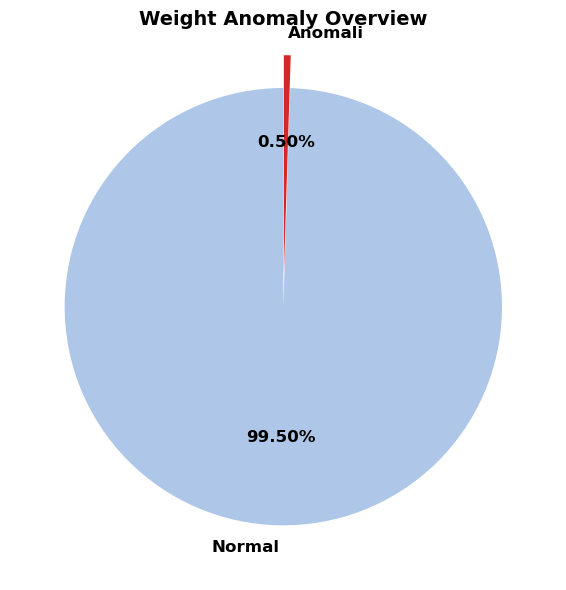

In [ ]:
plt.figure(figsize=(6,6))
weight_counts = shipments['is_weight_anomaly'].value_counts()
colors = ['#AEC7E8', '#D62728']  
explode = (0, 0.15)  

plt.pie(weight_counts, labels=['Normal', 'Anomali'], autopct='%1.2f%%',
        colors=colors, explode=explode, startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Weight Anomaly Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
data_bersih = shipments[shipments['is_weight_anomaly'] == False]
data_anomali = shipments[shipments['is_weight_anomaly'] == True]

Mengecek estimasi kebocoran pendapatan.

In [37]:
shipments.columns

Index(['awb_number', 'sender_id', 'origin_branch', 'dest_city', 'service_type',
       'payment_type', 'weight_kg', 'pickup_date', 'delivered_date', 'status',
       'is_logical_error', 'is_weight_anomaly'],
      dtype='object')

Dikarenakan tidak adanya tarif/harga, maka harga yang dicantumkan merupakan harga asumsi yaitu 10000/kg.

In [38]:
asumsi_tarif_per_kg = 10000

In [39]:
negative_weight = shipments[shipments['weight_kg'] < 0]
negative_weight.head()

,awb_number,sender_id,origin_branch,dest_city,service_type,payment_type,weight_kg,pickup_date,delivered_date,status,is_logical_error,is_weight_anomaly
270,JNE000000271,CUST-15377,B-091,Yogyakarta,reg,COD,-1.5,2023-09-29 09:00:00,2023-09-30 17:00:00,Delivered,False,True
780,JNE000000781,CUST-16908,B-121,Balikpapan,Reguler,Prepaid,-1.5,2023-09-17 15:00:00,2023-09-20 01:00:00,Delivered,False,True
810,JNE000000811,CUST-04001,B-047,Bandung,oke,Prepaid,-1.5,2023-06-29 09:00:00,2023-06-30 18:00:00,Delivered,False,True
1277,JNE000001278,CUST-09603,B-054,Jakarta,Yakin Esok Sampai,COD,-5.0,2023-09-29 18:00:00,2023-09-30 20:00:00,Delivered,False,True
1305,JNE000001306,CUST-17759,B-058,Palembang,REG,COD,-5.0,2023-05-31 13:00:00,2023-05-28 13:00:00,Delivered,True,True


In [40]:
negative_weight_loss = negative_weight['weight_kg'].abs().sum() * asumsi_tarif_per_kg
negative_weight_loss

np.float64(24415000.0)

In [41]:
print(f"Jumlah baris weight negatif: {len(negative_weight)}")
print(f"Estimasi kerugian: Rp {negative_weight_loss:,.0f}")

Jumlah baris weight negatif: 769
Estimasi kerugian: Rp 24,415,000


In [42]:
error_weight = shipments[shipments['weight_kg'] >100]
error_weight.head()

,awb_number,sender_id,origin_branch,dest_city,service_type,payment_type,weight_kg,pickup_date,delivered_date,status,is_logical_error,is_weight_anomaly
243,JNE000000244,CUST-18922,B-021,Jakarta,REG,COD,9999.0,2023-07-14 11:00:00,2023-07-20 21:00:00,Delivered,False,True
591,JNE000000592,CUST-13311,B-084,Balikpapan,REG,Prepaid,999.0,2023-07-31 15:00:00,2023-08-04 23:00:00,Delivered,False,True
668,JNE000000669,CUST-29778,B-065,Palembang,YES,COD,9999.0,2023-05-20 14:00:00,2023-05-22 23:00:00,Delivered,False,True
850,JNE000000851,CUST-23065,B-091,Surabaya,REG,Prepaid,999.0,2023-07-07 10:00:00,2023-07-08 11:00:00,Delivered,False,True
853,JNE000000854,CUST-01797,B-024,Bandung,reg,Prepaid,999.0,2023-05-15 08:00:00,2023-05-17 09:00:00,Delivered,False,True


In [84]:
# Melihat nominal berat yaang sekiranya merupakan berat yang error
error_weight['weight_kg'].unique()

array([9999.,  999.])

In [45]:
print(f"Terdapat {len(error_weight)} transaksi dengan weight yang tidak valid yang perlu diverifikasi secara manual")

Terdapat 731 transaksi dengan weight yang tidak valid yang perlu diverifikasi secara manual


Investigasi pola 731 baris dengan angka 999/9999 apakah terkonsentrasi ke branch tertentu atau tidak.

In [46]:
error_weight_per_branch = error_weight['origin_branch'].value_counts()
total_per_branch = shipments['origin_branch'].value_counts()
error_weight_rate = (error_weight_per_branch / total_per_branch * 100).sort_values(ascending=False)
error_weight_rate.head(10)

origin_branch
B-139    0.478011
B-092    0.458950
B-116    0.453858
B-123    0.445324
B-074    0.442696
B-007    0.438169
B-124    0.420168
B-024    0.412584
B-095    0.405268
B-019    0.405063
Name: count, dtype: float64

Temuan: Distribusi Weight Anomaly per Cabang

Analisis rate weight anomaly (nilai 999/9999) per cabang menunjukkan 
persebaran yang sangat merata — rate tertinggi hanya 0,48% (cabang B-139), 
bahkan sedikit di bawah rata-rata nasional (0,5%). 

Hal ini mengindikasikan bahwa error timbangan bersifat murni acak/random 
dan merupakan bug sistemik pada alat penimbang digital, bukan disebabkan 
oleh kesalahan oknum atau masalah operasional di cabang tertentu.

Rekomendasi: perbaikan sebaiknya difokuskan pada audit menyeluruh 
terhadap firmware/sistem alat timbangan digital di seluruh cabang, 
bukan investigasi spesifik ke cabang tertentu.

### 3. 4 Service Type Standardization

In [47]:
service_type_uniqe = shipments['service_type'].value_counts()
service_type_uniqe

service_type
REG                      89984
YES                      44981
OKE                      30140
oke                      30061
Reguler                  29943
reg                      29908
Yakin Esok Sampai        15099
yes                      14960
Ongkos Kirim Ekonomis    14924
Name: count, dtype: int64

In [48]:
shipments['service_type_clean'] = shipments['service_type'].str.upper()

In [49]:
new_service_type_name = {
    'REGULER': 'REG',
    'YAKIN ESOK SAMPAI': 'YES',
    'ONGKOS KIRIM EKONOMIS': 'OKE'
}
shipments['service_type_clean'] = shipments['service_type_clean'].replace(new_service_type_name)

In [50]:
shipments['service_type_clean'].value_counts()

service_type_clean
REG    149835
OKE     75125
YES     75040
Name: count, dtype: int64

**Temuan: Standardisasi Service Type**

Ditemukan 9 variasi penulisan untuk 3 jenis layanan JNE (REG, YES, OKE), 
disebabkan oleh input manual dari agen tanpa standar penulisan yang 
seragam. Contohnya, layanan REG tercatat dalam 3 bentuk berbeda: 
"REG", "reg", dan "Reguler".

Sebelum dibersihkan, angka REG yang terbaca hanya 119.892 (mengabaikan 
variasi "Reguler" sebanyak 29.943), sehingga terjadi selisih 20% dari 
angka yang seharusnya (149.835). Kesalahan pembacaan seperti ini dapat 
membuat manajemen salah menilai performa/popularitas suatu layanan.

Setelah dibersihkan, distribusi penggunaan layanan JNE adalah:
- REG: 149.835 (49,9%)
- OKE: 75.125 (25,0%)
- YES: 75.040 (25,0%)

Layanan REG mendominasi hampir separuh dari seluruh transaksi, 
mengindikasikan mayoritas pelanggan JNE lebih memilih opsi 
ekonomis/reguler dibanding layanan cepat (YES) atau ekonomis 
super hemat (OKE), yang keduanya justru terdistribusi hampir seimbang.

## **4. FEATURE ENGINEERING & EDA**

### 4.1 SLA Miss

In [51]:
shipments_valid = shipments[shipments['is_logical_error'] == False].copy()
shipments_valid['service_type'] = shipments_valid['service_type_clean']
shipments_valid['delivery_time'] = (shipments_valid['delivered_date'] - shipments_valid['pickup_date']).dt.days

In [52]:
shipments_valid['delivery_time'].describe()

count    292527.000000
mean          3.495783
std           1.707501
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: delivery_time, dtype: float64

Membuat kolom SLA status.

In [ ]:
# Asumsi SLA per jenis layanan (tidak tersedia di data resmi) 
asumsi_sla = {
    'YES' : 1,
    'REG' : 3,
    'OKE': 6
}
shipments_valid['sla_limit'] = shipments_valid['service_type_clean'].replace(asumsi_sla)
shipments_valid['is_sla_miss'] = shipments_valid['delivery_time'] > shipments_valid['sla_limit']

C:\Users\User\AppData\Local\Temp\ipykernel_20056\2743472201.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shipments_valid['sla_limit'] = shipments_valid['service_type_clean'].replace(asumsi_sla)


In [54]:
shipments_valid['is_sla_miss'].mean() * 100

np.float64(45.78961941974587)

In [55]:
shipments_valid['is_sla_miss'].value_counts()

is_sla_miss
False    158580
True     133947
Name: count, dtype: int64

In [56]:
shipments_valid.groupby('service_type_clean')['is_sla_miss'].mean() * 100

service_type_clean
OKE     0.000000
REG    49.833252
YES    83.592042
Name: is_sla_miss, dtype: float64

In [57]:
print(shipments_valid.groupby('service_type_clean')['delivery_time'].describe())

                       count      mean       std  min  25%  50%  75%  max
service_type_clean                                                       
OKE                  73314.0  3.490848  1.705702  1.0  2.0  3.0  5.0  6.0
REG                 146029.0  3.490512  1.708649  1.0  2.0  3.0  5.0  6.0
YES                  73184.0  3.511246  1.706938  1.0  2.0  4.0  5.0  6.0


Breakdown SLA Miss per-cabang.

In [58]:
sla_miss_per_branch = shipments_valid.groupby('origin_branch')['is_sla_miss'].mean() * 100
sla_miss_per_branch.sort_values(ascending=False).head(10)

origin_branch
B-056    48.527132
B-091    48.092002
B-015    47.995941
B-035    47.776033
B-144    47.775531
B-128    47.730750
B-045    47.540161
B-093    47.519182
B-063    47.452547
B-066    47.357826
Name: is_sla_miss, dtype: float64

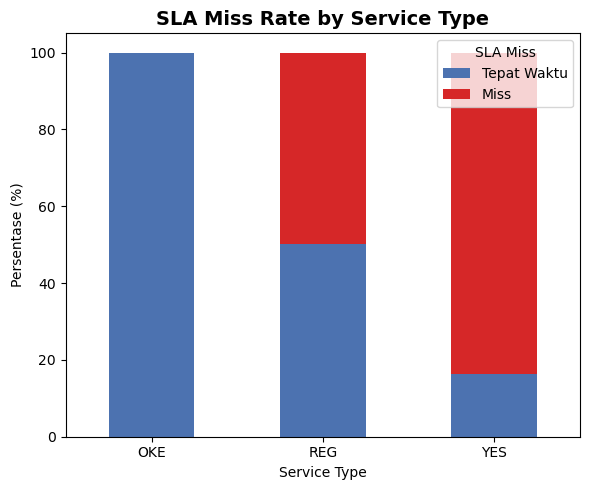

In [59]:
sla_per_service_pct = shipments_valid.groupby('service_type_clean')['is_sla_miss'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(6,5))
sla_per_service_pct.plot(kind='bar', stacked=True, color=['#4C72B0', '#D62728'], ax=plt.gca())
plt.title('SLA Miss Rate by Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Service Type')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(['Tepat Waktu', 'Miss'], title='SLA Miss')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20056\2622363247.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shipments_valid, x='is_sla_miss', palette=['#4C72B0', '#D62728'])


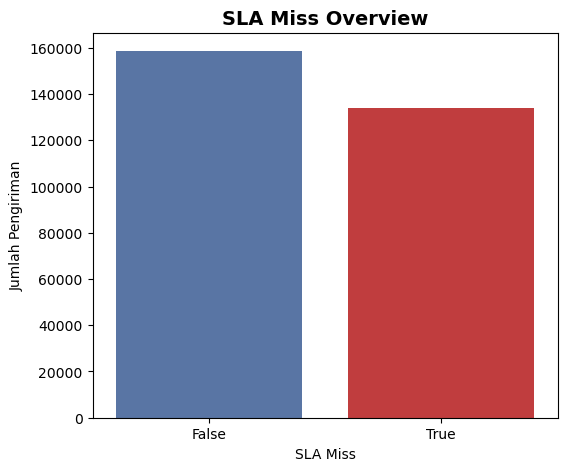

In [60]:
plt.figure(figsize=(6,5))
sns.countplot(data=shipments_valid, x='is_sla_miss', palette=['#4C72B0', '#D62728'])
plt.title('SLA Miss Overview', fontsize=14, fontweight='bold')
plt.xlabel('SLA Miss')
plt.ylabel('Jumlah Pengiriman')
plt.show()

**Temuan: SLA Miss dan Breakdown per Cabang**

Secara keseluruhan, tingkat SLA Miss JNE mencapai 45,79%. Breakdown 
per service_type menunjukkan pola yang tidak lazim: layanan YES 
(express) justru memiliki rate SLA Miss tertinggi (83,59%), sementara 
OKE (ekonomis) memiliki rate terendah (0%). 

Setelah ditelusuri lebih lanjut, penyebabnya bukan karena masalah 
operasional di cabang tertentu, melainkan karena durasi pengiriman 
aktual (delivery_time) untuk ketiga jenis layanan ternyata HAMPIR 
IDENTIK (rata-rata 3,49-3,51 hari), padahal SLA yang dijanjikan 
sangat berbeda (YES=1 hari, REG=3 hari, OKE=6 hari).

Analisis breakdown per cabang (origin_branch) turut mengonfirmasi hal 
ini — rate SLA Miss tertinggi hanya 48,53% (cabang B-056), tidak jauh 
berbeda dari rata-rata nasional 45,79%. Hal ini membuktikan bahwa 
permasalahan SLA Miss bersifat SISTEMIK dan MERATA di seluruh cabang, 
bukan disebabkan oleh kinerja buruk cabang tertentu.

**Kesimpulan Utama:** JNE tidak benar-benar mendiferensiasikan 
kecepatan pengiriman sesuai janji layanan. Pelanggan yang membayar 
lebih mahal untuk layanan YES (express) pada kenyataannya tidak 
mendapatkan pengiriman yang lebih cepat dibandingkan REG atau OKE.

### 4.2 RTS vs COD

In [61]:
shipments['payment_type'].value_counts()

payment_type
Prepaid    195091
COD        104909
Name: count, dtype: int64

In [62]:
shipments['status'].value_counts()

status
Delivered    249113
RTS           35867
Damaged        8926
Lost           6094
Name: count, dtype: int64

In [63]:
tabel_silang = pd.crosstab(shipments['payment_type'], shipments['status'])
tabel_silang

status,Damaged,Delivered,Lost,RTS
payment_type,,,,
COD,3126,73501,2094,26188
Prepaid,5800,175612,4000,9679


In [64]:
total_cod = tabel_silang.loc['COD'].sum()
persentase_rts_cod = tabel_silang.loc['COD', 'RTS'] / total_cod * 100

print(f"Total COD: {total_cod}")
print(f"Persentase RTS COD: {persentase_rts_cod:.2f}%")

total_prepaid = tabel_silang.loc['Prepaid'].sum()
persentase_rts_prepaid = tabel_silang.loc['Prepaid', 'RTS'] / total_prepaid * 100

print(f"Total Prepaid: {total_prepaid}")
print(f"Persentase RTS Prepaid: {persentase_rts_prepaid:.2f}%")

Total COD: 104909
Persentase RTS COD: 24.96%
Total Prepaid: 195091
Persentase RTS Prepaid: 4.96%


Melakukan pengecekan apakah terjadi pada region tertentu.

In [65]:
data_cod = shipments[shipments['payment_type'] == 'COD']
len(data_cod)

104909

In [66]:
rts_cod = data_cod[data_cod['status'] == 'RTS'] 
total_cod_per_kota = data_cod['dest_city'].value_counts() 
rts_per_kota = rts_cod['dest_city'].value_counts() 
presentase_cod_per_kota = (rts_per_kota / total_cod_per_kota) * 100
presentase_cod_per_kota.sort_values(ascending=False).head(10)

dest_city
Jakarta       25.704192
Denpasar      25.584515
Palembang     25.145474
Medan         25.076104
Surabaya      24.878003
Balikpapan    24.786000
Semarang      24.776550
Makassar      24.742857
Bandung       24.705547
Yogyakarta    24.226110
Name: count, dtype: float64

Sebaran regional: masalah RTS-COD ini tidak terkonsentrasi di kota tertentu, melainkan tersebar merata — mengindikasikan ini masalah karakteristik metode pembayaran COD itu sendiri (perilaku pembeli), bukan masalah infrastruktur/operasional di daerah tertentu.

Estimasi biaya kerugian materil akibat RTS

In [67]:
asumsi_biaya_rts = 15000
jumlah_rts_cod = len(rts_cod)
total_kerugian_rts = jumlah_rts_cod * asumsi_biaya_rts
print(f"Estimasi total kerugian dari RTS COD: Rp {total_kerugian_rts:,.0f}")

Estimasi total kerugian dari RTS COD: Rp 392,820,000


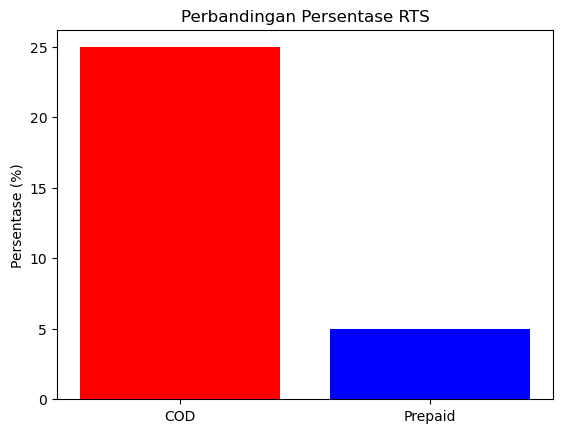

In [68]:
metode = ["COD", "Prepaid"]
persentase_rts = [persentase_rts_cod, persentase_rts_prepaid]

plt.bar(metode, persentase_rts, color=["red", "blue"])

plt.title("Perbandingan Persentase RTS")
plt.ylabel("Persentase (%)")
plt.show()

**Temuan: RTS pada Metode Pembayaran COD**

Berdasarkan data yang ada, tingkat retur (RTS) pada metode pembayaran COD tercatat sebesar 24,96%, jauh lebih tinggi dibandingkan metode Non-COD yang hanya 4,96%. Temuan ini mengonfirmasi dugaan pada latar belakang bisnis JNE, bahwa paket COD memang rentan mengalami RTS akibat penolakan pembayaran oleh pembeli atau alamat tujuan yang fiktif.

Dari sisi dampak finansial, dengan asumsi biaya operasional sebesar Rp15.000 per kejadian RTS, dan total kejadian RTS pada COD sebanyak 26.188 transaksi, estimasi kerugian yang ditanggung JNE mencapai **Rp392.820.000**. Angka ini jauh lebih besar dibandingkan kerugian pada kasus weight anomaly sebelumnya, yang diasumsikan sebesar Rp10.000 per kg dan dihitung dari 769 transaksi dengan berat negatif, menghasilkan estimasi kerugian sebesar Rp24.415.000. Dengan kata lain, dampak finansial dari RTS COD kurang lebih 16 kali lipat lebih besar dibandingkan kasus weight anomaly.

Selain kerugian materiil, tingginya angka RTS pada COD juga berpotensi menurunkan kepercayaan seller terhadap layanan JNE, yang pada akhirnya dapat merugikan kedua belah pihak — baik JNE maupun seller yang menggunakan jasanya.

**Rekomendasi**

JNE disarankan untuk memperketat proses verifikasi alamat pengiriman guna mengurangi risiko alamat fiktif, serta menerapkan sistem filter atau skor kelayakan pembeli untuk memastikan transaksi COD dilakukan oleh pembeli yang bertanggung jawab.

Jika JNE memiliki keterbatasan sumber daya (waktu maupun anggaran) untuk menangani kedua permasalahan sekaligus, penanganan RTS pada COD sebaiknya diprioritaskan terlebih dahulu. Hal ini didasarkan pada dampak finansial yang jauh lebih besar (16 kali lipat) serta volume kejadian yang jauh lebih tinggi (26.188 dibandingkan 769 transaksi), sehingga perbaikan pada aspek ini berpotensi memberikan penghematan biaya operasional yang jauh lebih signifikan bagi JNE.

### 4.3 Missing Customer Type 

Menghitung data customer missing per kota.

In [69]:
customers['customer_type'].isnull().sum()
persentase_missing = customers['customer_type'].isnull().sum() / len(customers) * 100
print(f"{persentase_missing:.2f}%")

15.26%


In [70]:
data_missing = customers[customers['customer_type'].isnull()]
total_customer_per_kota = customers['city'].value_counts()
missing_per_kota = data_missing['city'].value_counts()
presentase_missing_per_kota = (missing_per_kota / total_customer_per_kota) * 100

top_10_missing = presentase_missing_per_kota.sort_values(ascending=False).head(10)
top_10_missing

city
Bandung       15.879397
Semarang      15.805471
Jakarta       15.554811
Balikpapan    15.466313
Medan         15.356791
Yogyakarta    15.275081
Makassar      15.096817
Denpasar      15.011860
Surabaya      14.768076
Palembang     14.414414
Name: count, dtype: float64

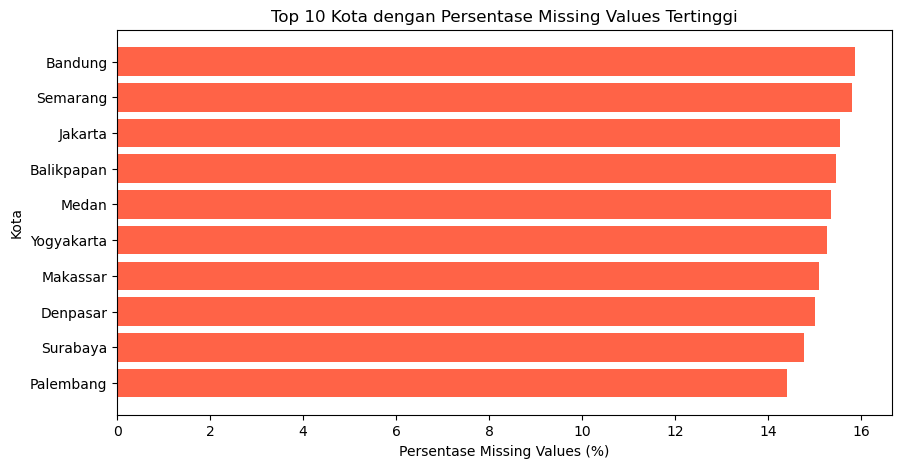

In [71]:
plt.figure(figsize=(10, 5))
plt.barh(top_10_missing.index, top_10_missing.values, color='tomato')

plt.title('Top 10 Kota dengan Persentase Missing Values Tertinggi')
plt.xlabel('Persentase Missing Values (%)')
plt.ylabel('Kota')

plt.gca().invert_yaxis()

plt.show()

**Kesimpulan: Missing Values pada Customer Type**

Berdasarkan data yang ada, rate missing values pada customer_type di berbagai kota berkisar antara 14,41% - 15,88%, tidak jauh berbeda dari rata-rata keseluruhan sebesar 15,26%. Hal ini menunjukkan bahwa missing values tersebut tidak terkonsentrasi di kota tertentu, melainkan tersebar merata di seluruh kota.

Temuan ini konsisten dengan pola yang sudah ditemukan pada analisis-analisis sebelumnya:

Logical error: rentang ±1,4 poin dari rata-rata
Weight anomaly: rentang di bawah rata-rata
RTS-COD: rentang ±1,5 poin dari rata-rata

Konsistensi pola ini membuktikan bahwa berbagai permasalahan data pada JNE bersifat sistemik dan tersebar secara nasional, bukan disebabkan oleh faktor lokal di kota atau cabang tertentu. Hal ini menjadi bahan evaluasi penting bagi JNE untuk membenahi sistem secara menyeluruh, bukan melakukan audit parsial ke lokasi tertentu.

Secara khusus, missing values pada customer_type turut menghambat tim Sales dalam melakukan segmentasi pelanggan (Corporate vs Individual) untuk strategi cross-selling. Tanpa informasi jenis pelanggan yang lengkap, promosi yang ditargetkan menjadi kurang efektif dan berpotensi kehilangan peluang bisnis tambahan.

**Rekomendasi:**

Missing values customer_type: JNE disarankan menjadikan kolom customer_type sebagai field wajib (mandatory) pada proses registrasi pelanggan baru, sehingga kelengkapan data terjamin sejak awal dan tim Sales dapat melakukan segmentasi cross-selling secara optimal.
Logical error & weight anomaly: Diperlukan pembenahan sistem input untuk mencegah kesalahan penginputan manual yang tidak sesuai standar, misalnya dengan menambahkan validasi otomatis pada aplikasi input agen (mencegah nilai berat negatif/tidak wajar, serta mencegah timestamp yang tidak logis).
RTS-COD: Diperlukan sistem verifikasi alamat yang lebih akurat serta mekanisme filtering pembeli berkualitas, guna mengurangi risiko alamat fiktif dan penolakan pembayaran COD.

Secara keseluruhan, seluruh temuan ini dapat menjadi bahan evaluasi bagi JNE untuk membangun sistem yang lebih efisien — baik dari sisi operasional, maupun dari sisi kepercayaan pelanggan dan mitra seller, yang pada akhirnya akan berdampak positif bagi keberlanjutan bisnis JNE sendiri.

## **5. UJI STATISTIK**

### 5.1 Chi-Square Test (RTS vs Payment Type)

Untuk membuktikan signifikansi hubungan antara payment_type dan status secara statistik

In [72]:
chi2, p_value, dof, expected = chi2_contingency(tabel_silang)
print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

Chi-Square Statistic: 26100.381934372395
P-value: 0.0


**Uji Statistik: Chi-Square Test — RTS vs Metode Pembayaran**

Untuk membuktikan secara formal apakah hubungan antara metode pembayaran (COD/Prepaid) dan status RTS bersifat signifikan atau hanya kebetulan, dilakukan uji Chi-Square Test of Independence.

**Hasil:**

Chi-Square Statistic: 26.100,38
P-value: < 0,001

Interpretasi: Dengan p-value jauh di bawah ambang batas 0,05, hasil ini membuktikan secara statistik bahwa metode pembayaran (COD) memiliki hubungan yang signifikan dengan tingkat RTS, memperkuat temuan deskriptif sebelumnya bahwa COD berasosiasi dengan risiko RTS yang jauh lebih tinggi dibanding Prepaid (24,96% vs 4,96%). Hasil uji ini memberikan dasar statistik yang kuat untuk rekomendasi bisnis terkait mitigasi risiko COD yang telah diusulkan sebelumnya.

### 5.2 ANOVA (Durasi antar Service Type)

In [73]:
durasi_reg = shipments_valid[shipments_valid['service_type_clean'] == 'REG']['delivery_time']
durasi_yes = shipments_valid[shipments_valid['service_type_clean'] == 'YES']['delivery_time']
durasi_oke = shipments_valid[shipments_valid['service_type_clean'] == 'OKE']['delivery_time']

In [74]:
f_stat, p_value = f_oneway(durasi_reg, durasi_yes, durasi_oke)

print(f"F-Statistic: {f_stat}")
print(f"P-value: {p_value}")

F-Statistic: 4.002835450367885
P-value: 0.018264779748908395


**Uji Statistik: ANOVA — Durasi Pengiriman antar Service Type**

Untuk membuktikan secara formal apakah perbedaan durasi pengiriman antar jenis layanan (REG, YES, OKE) bersifat signifikan, dilakukan uji One-Way ANOVA.

**Hasil:**

F-Statistic: 4,00
P-value: 0,018

**Interpretasi:** Dengan p-value di bawah 0,05, hasil ini menunjukkan bahwa secara statistik terdapat perbedaan rata-rata durasi pengiriman antar ketiga jenis layanan. Namun, perlu dicatat bahwa dengan jumlah data yang sangat besar (300.000 baris), uji statistik menjadi sangat sensitif sehingga mampu mendeteksi perbedaan sekecil apapun sebagai "signifikan" — termasuk perbedaan yang secara praktis tidak bermakna.

Perbedaan rata-rata durasi antar layanan hanya sekitar 0,02 hari (kurang dari 1 jam) — selisih yang tidak relevan secara praktis bagi pelanggan yang membayar lebih mahal untuk layanan YES (express) dibandingkan REG atau OKE. Dengan demikian, hasil uji ANOVA ini tidak mengubah kesimpulan dan rekomendasi bisnis sebelumnya: JNE tetap perlu melakukan diferensiasi operasional yang nyata antar jenis layanan, karena secara praktis pelanggan tidak merasakan perbedaan signifikan dari segi waktu pengiriman meski membayar tarif berbeda.

## **6. GOALS**

### **6.1** Route & Hub Optimization

**Goals:** Route & Hub Optimization

**Status:** Teridentifikasi, implementasi diperlukan

**Bukti dari Analisis:**
Berdasarkan data yang ada, ditemukan bahwa tingkat SLA Miss secara keseluruhan mencapai 45,79%. Setelah ditelusuri lebih lanjut, penyebab utamanya adalah durasi pengiriman aktual untuk ketiga jenis layanan (REG, YES, OKE) yang ternyata hampir identik (rata-rata 3,49-3,51 hari), padahal SLA yang dijanjikan sangat berbeda antar layanan (YES=1 hari, REG=3 hari, OKE=6 hari).

Analisis breakdown per cabang (origin_branch) turut mengonfirmasi temuan ini — rate SLA Miss tertinggi hanya 48,53% (cabang B-056), tidak jauh berbeda dari rata-rata nasional 45,79%. Hal ini membuktikan bahwa permasalahan SLA Miss bersifat sistemik dan merata di seluruh cabang, bukan disebabkan oleh kinerja buruk cabang tertentu.

Dengan demikian, dapat disimpulkan bahwa pendekatan evaluasi kinerja cabang secara individual — sebagaimana diusulkan pada Goals awal — tidak relevan untuk permasalahan ini, karena akar masalahnya bukan terletak pada operasional cabang, melainkan pada kebijakan dan proses operasional JNE secara nasional.

**Catatan/Rekomendasi:**
Mengingat sifat permasalahan yang bersifat nasional dan sistemik, JNE disarankan untuk menerapkan sejumlah langkah berikut:

Diferensiasi operasional layanan — mengadakan prioritas rute dan alokasi kurir khusus untuk paket dengan layanan YES, sehingga pelanggan yang membayar lebih untuk kecepatan benar-benar merasakan perbedaan signifikan dibandingkan layanan REG atau OKE.
Evaluasi ulang definisi SLA — perlu dikaji apakah target SLA 1 hari untuk layanan YES realistis untuk dicapai dengan infrastruktur operasional saat ini. Apabila target tersebut memungkinkan, diperlukan percepatan proses operasional pendukung (sorting, distribusi, dan pengantaran). Apabila tidak realistis, JNE perlu mempertimbangkan revisi SLA yang lebih akurat.
Transparansi estimasi waktu kepada pelanggan — JNE disarankan memberikan informasi estimasi waktu pengiriman yang lebih akurat kepada pelanggan, guna menghindari persepsi "janji palsu" dan mengurangi kekecewaan pelanggan akibat keterlambatan dari waktu yang dijanjikan.

### **6.2** COD Risk Management

**Goals: COD Risk Management**

**Status:** Tercapai (dengan catatan revisi pendekatan)

**Bukti dari Analisis:**
Berdasarkan data yang ada, tingkat retur (RTS) pada metode pembayaran COD tercatat sebesar 24,96%, jauh lebih tinggi dibandingkan metode Non-COD yang hanya 4,96%. Temuan ini mengonfirmasi dugaan pada latar belakang bisnis JNE, bahwa paket COD memang rentan mengalami RTS akibat penolakan pembayaran oleh pembeli atau alamat tujuan yang fiktif.

Dari sisi dampak finansial, dengan asumsi biaya operasional sebesar Rp15.000 per kejadian RTS dan total kejadian RTS pada COD sebanyak 26.188 transaksi, estimasi kerugian yang ditanggung JNE mencapai Rp392.820.000 — sekitar 16 kali lipat lebih besar dibandingkan kerugian pada kasus weight anomaly (Rp24.415.000). Selain kerugian materiil, tingginya angka RTS pada COD juga berpotensi menurunkan kepercayaan seller terhadap layanan JNE.

Lebih lanjut, hasil analisis per kota menunjukkan bahwa RTS pada COD **tersebar merata di seluruh wilayah** (berkisar 24,23%-25,70%), tidak terkonsentrasi pada daerah tertentu. Temuan ini mengindikasikan bahwa pendekatan **blacklist atau pengetatan aturan per daerah** — sebagaimana diusulkan pada Goals awal — **kurang efektif** untuk diterapkan, karena akar permasalahan bukan bersifat regional, melainkan terkait dengan karakteristik risiko metode pembayaran COD itu sendiri.

**Catatan/Rekomendasi:**
Mengingat sifat permasalahan yang merata secara nasional, JNE disarankan untuk menerapkan kebijakan mitigasi risiko COD secara **menyeluruh**, bukan terbatas pada daerah tertentu. Beberapa langkah yang dapat dilakukan antara lain memperketat proses verifikasi alamat pengiriman guna mengurangi risiko alamat fiktif, serta menerapkan sistem filter atau skor kelayakan pembeli untuk memastikan transaksi COD dilakukan oleh pembeli yang bertanggung jawab.

Apabila JNE memiliki keterbatasan sumber daya (waktu maupun anggaran) untuk menangani seluruh permasalahan sekaligus, penanganan RTS pada COD sebaiknya diprioritaskan terlebih dahulu dibandingkan weight anomaly. Hal ini didasarkan pada dampak finansial yang jauh lebih besar (16 kali lipat) serta volume kejadian yang jauh lebih tinggi (26.188 dibandingkan 769 transaksi), sehingga perbaikan pada aspek ini berpotensi memberikan penghematan biaya operasional yang jauh lebih signifikan bagi JNE.

### **6.3** Revenue Recovery

**Goals: Revenue Recovery**

**Status:** Tercapai

**Bukti dari Analisis:**
Hasil analisis menunjukkan terdapat 769 baris data dengan nilai berat (weight_kg) negatif, yang mengindikasikan kesalahan input manual oleh agen, serta 731 baris dengan nilai berat tidak wajar (999/9999 kg), yang mengindikasikan adanya bug pada sistem timbangan digital. Kedua anomali ini menyebabkan estimasi kerugian pendapatan bagi JNE sebesar Rp24.415.000 (dengan asumsi tarif Rp10.000/kg).

Lebih lanjut, hasil analisis per cabang menunjukkan bahwa anomali tersebut tidak terkonsentrasi pada wilayah atau cabang tertentu, melainkan tersebar merata di seluruh wilayah operasional. Temuan ini mengindikasikan bahwa permasalahan yang terjadi bersifat sistemik — baik dari sisi kesalahan input manual maupun kegagalan sistem — dan bukan disebabkan oleh tindak kecurangan atau kelalaian pada cabang tertentu. Oleh karena itu, pendekatan audit yang terfokus pada satu atau dua cabang tidak diperlukan; permasalahan ini perlu ditangani melalui perbaikan sistem secara menyeluruh.

**Catatan/Rekomendasi:**
Berdasarkan temuan tersebut, JNE disarankan untuk melakukan pembenahan sistem input data guna meminimalkan kesalahan pada level agen, sehingga potensi kebocoran omzet akibat kesalahan perhitungan ongkos kirim dapat dikurangi. JNE juga disarankan untuk menerapkan standar dan validasi input yang seragam di seluruh wilayah operasional, guna memastikan konsistensi dan keakuratan data yang tercatat. Selain itu, diperlukan mekanisme pemantauan berkala terhadap proses input data oleh agen, untuk mencegah terulangnya kesalahan serupa di masa mendatang.

### **6.4** Data Realibility

**Goals: Data Reliability**

**Status:** Tercapai

**Bukti dari Analisis:**
Ditemukan 7.473 dari 300.000 baris data (2,49%) dengan kondisi `delivered_date` tercatat lebih awal dari `pickup_date` — sebuah kondisi yang mustahil secara logika. Setelah dianalisis lebih lanjut per cabang, rate error tertinggi hanya berkisar 3-3,9% (cabang B-055 sebagai yang tertinggi), tidak jauh berbeda dari rata-rata nasional 2,49%. Hal ini mengindikasikan bahwa error bersifat tersebar merata (sistemik), bukan terkonsentrasi akibat kesalahan oknum atau alat yang rusak di cabang tertentu.

**Catatan/Rekomendasi:**
Sama seperti temuan pada weight anomaly, perbaikan sebaiknya difokuskan pada infrastruktur sistem scanning secara menyeluruh, bukan audit spesifik ke cabang tertentu. JNE disarankan untuk menerapkan sistem penanggalan yang akurat, sehingga tidak memungkinkan tercatatnya tanggal pengiriman sampai yang lebih awal dari tanggal penjemputan.

Pembersihan logical error ini menjadi langkah krusial bagi JNE, mengingat data timestamp yang tidak valid akan berdampak langsung pada validitas perhitungan durasi pengiriman dan SLA. Apabila data ini tidak dibersihkan terlebih dahulu, perhitungan durasi pengiriman berpotensi menghasilkan nilai yang tidak masuk akal (negatif), sehingga dashboard performa kurir dan SLA yang ditampilkan kepada manajemen menjadi tidak akurat dan tidak dapat dipertanggungjawabkan. Dengan demikian, penanganan logical error ini merupakan prasyarat utama untuk mencapai keandalan data (data reliability) yang menyeluruh pada sistem JNE.

## **7. KESIMPULAN & LIMITASI**

### 7.1 Ringkasan Keseluruhan

Analisis terhadap 300.000 data pengiriman JNE ini berhasil menjawab seluruh Problem Statement dan Goals yang ditetapkan di awal. Proses dimulai dari pemeriksaan kualitas data, yang mengungkap beberapa masalah signifikan: 7.473 baris (2,49%) logical error pada timestamp, 1.500 baris (0,5%) anomali berat paket, dan 9 variasi penulisan tidak konsisten pada kolom service_type. Setelah data dibersihkan dan distandarisasi, analisis lanjutan mengungkap temuan utama yang menjawab Masalah Utama JNE:

Pertama, tingkat SLA Miss mencapai 45,79%, disebabkan oleh durasi pengiriman yang hampir identik antar jenis layanan meski SLA yang dijanjikan berbeda signifikan — sebuah temuan sistemik yang dikonfirmasi tersebar merata di seluruh cabang. Kedua, metode pembayaran COD memiliki tingkat retur (RTS) 24,96%, lima kali lebih tinggi dibanding Non-COD, dengan estimasi kerugian operasional mencapai Rp392.820.000 — hubungan ini telah dibuktikan signifikan secara statistik melalui Chi-Square Test. Ketiga, kesalahan input data agen menyebabkan estimasi kebocoran pendapatan sebesar Rp24.415.000.

Seluruh temuan ini memiliki benang merah yang konsisten: anomali tersebar merata secara geografis, mengindikasikan bahwa akar masalah bersifat sistemik (terkait kebijakan dan infrastruktur JNE secara nasional), bukan disebabkan oleh kinerja buruk cabang atau daerah tertentu. Implikasinya, solusi yang direkomendasikan turut disusun secara nasional dan menyeluruh, bukan berupa audit atau intervensi lokal.

### 7.2 Limitasi Analisis

Beberapa keterbatasan penting perlu disampaikan secara transparan terkait analisis ini:

**1. Asumsi tarif pengiriman** 
Dataset tidak menyediakan kolom harga/tarif resmi, sehingga estimasi kerugian finansial (revenue leakage dari weight anomaly dan kerugian dari RTS-COD) dihitung menggunakan asumsi tarif Rp10.000/kg dan Rp15.000 per kejadian RTS. Angka ini adalah estimasi kasar berdasarkan logika bisnis, bukan data resmi dari JNE.

**2. Asumsi SLA per jenis layanan** 
Karena dataset tidak mencantumkan SLA resmi, threshold SLA (YES=1 hari, REG=3 hari, OKE=6 hari) ditetapkan berdasarkan asumsi yang masuk akal dari nama layanan dan pola distribusi data. Threshold yang berbeda berpotensi menghasilkan persentase SLA Miss yang berbeda pula.

**3. Estimasi kerugian weight negatif** 
Perhitungan kerugian dari weight_kg negatif mengasumsikan nilai absolut sebagai representasi berat sebenarnya — pendekatan ini adalah estimasi, bukan fakta yang terverifikasi, karena berat asli yang sebenarnya tidak dapat diketahui dari data yang tersedia.

**4. Data bersifat simulasi** 
Sebagai dataset yang dirancang untuk keperluan pembelajaran, beberapa pola dalam data (misalnya durasi pengiriman yang hampir identik antar service_type) mungkin mencerminkan desain dataset, bukan sepenuhnya kondisi operasional JNE yang sebenarnya. Namun, temuan ini tetap diperlakukan sebagai insight yang sah untuk dianalisis dan direkomendasikan solusinya, sesuai arahan yang diperoleh selama proses analisis.

**5. Analisis bersifat deskriptif dan diagnostik, belum prediktif** 
Seluruh temuan dalam analisis ini menjelaskan pola yang SUDAH terjadi (data historis), belum mencakup kemampuan untuk memprediksi kejadian di masa depan (misalnya, memprediksi paket mana yang berisiko RTS sebelum benar-benar dikirim).

### 7.3 Next Steps 

Beberapa arah pengembangan yang dapat dilakukan jika tersedia waktu dan sumber daya lebih lanjut:

**1. Verifikasi data dengan pihak JNE** — memperoleh data tarif resmi dan SLA resmi per layanan untuk menggantikan asumsi yang digunakan dalam analisis ini, sehingga estimasi finansial dan SLA Miss menjadi lebih akurat.

**2. Pengembangan model prediktif (Machine Learning)** — sebagai kelanjutan dari analisis deskriptif ini, dataset yang telah dibersihkan berpotensi digunakan untuk membangun model klasifikasi yang memprediksi kemungkinan suatu paket akan mengalami RTS atau SLA Miss sebelum pengiriman dilakukan, berdasarkan fitur seperti payment_type, dest_city, dan service_type. Model semacam ini dapat mendukung sistem peringatan dini (early warning system) bagi JNE.

**3. Analisis pola musiman** — mengeksplorasi apakah SLA Miss dan RTS mengalami lonjakan pada periode tertentu (misalnya saat kampanye belanja online/harbolnas), sesuai konteks yang disebutkan pada latar belakang bisnis JNE.

**4. Dashboard monitoring real-time** — mengembangkan dashboard Tableau yang telah dibuat menjadi alat pemantauan berkelanjutan bagi manajemen JNE, memungkinkan deteksi dini terhadap lonjakan anomali data maupun penurunan performa operasional.

## **8. EXPORT DATA UNTUK VISUALISASI**

Untuk keperluan visualisasi lanjutan di Tableau Public, ketiga tabel 
(shipments, branches, customers) yang telah melalui proses cleaning 
digabungkan menjadi satu dataset final, kemudian diekspor dalam 
format CSV.

In [86]:
shipments['delivery_time'] = (shipments['delivered_date'] - shipments['pickup_date']).dt.days
shipments['sla_limit'] = shipments['service_type_clean'].map(asumsi_sla)
shipments['is_sla_miss'] = shipments['delivery_time'] > shipments['sla_limit']

shipments.loc[shipments['is_logical_error'], ['delivery_time', 'is_sla_miss']] = np.nan

C:\Users\User\AppData\Local\Temp\ipykernel_20056\90322856.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  shipments.loc[shipments['is_logical_error'], ['delivery_time', 'is_sla_miss']] = np.nan


In [76]:
df_final = shipments.merge(branches, left_on='origin_branch', right_on='branch_code', how='left')
df_final = df_final.merge(customers, left_on='sender_id', right_on='customer_id', how='left')
df_final.shape

(300000, 22)

In [77]:
df_final.to_csv('jne_data_clean.csv', index=False)

In [78]:
cek_ulang = pd.read_csv('jne_data_clean.csv')
cek_ulang.columns

Index(['awb_number', 'sender_id', 'origin_branch', 'dest_city', 'service_type',
       'payment_type', 'weight_kg', 'pickup_date', 'delivered_date', 'status',
       'is_logical_error', 'is_weight_anomaly', 'service_type_clean',
       'delivery_time', 'sla_limit', 'is_sla_miss', 'branch_code',
       'branch_name', 'region', 'customer_id', 'city', 'customer_type'],
      dtype='object')